# Detekcija phishing email-ova
### Skup podataka: IWSPA-AP (No-Header)
### Modeli: Random Forest · XGBoost · GPT-4o-mini (zero-shot) · Fino podešeni DistilBERT

---
**Pregled pipeline-a:**
 1. Učitavanje sirovih podataka  ->  2. Čišćenje i predobrada  ->  3. Dedupliciranje  ->  4. Spajanje i označavanje   ->  5. EDA  ->  6. Inženjering karakteristika -> 7. Podela na train/test -> 8. Klasični ML -> 9. GPT zero-shot -> 10. Analiza grešaka GPT-a -> 11. Fino podešavanje DistilBERT-a -> 12. Poređenje

In [19]:
import os
import re
import email
import hashlib
import csv
import warnings
import random
from pathlib import Path

import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

BASE_DIR   = Path(".")
RAW_DIR    = BASE_DIR / "data" / "raw"
PROC_DIR   = BASE_DIR / "data" / "processed"
PROC_DIR.mkdir(parents=True, exist_ok=True)

# IWSPA-only (No-Header) configuration
IWSPA_NH = RAW_DIR / "IWSPA" / "IWSPA2.0_Training_No_Header"

iwspa_ok = (IWSPA_NH / "phish").exists() and (IWSPA_NH / "legit").exists()
print("Paths OK (IWSPA-NH):", iwspa_ok)

Paths OK (IWSPA-NH): True


---
## Sekcija 1 — Učitavanje sirovog skupa podataka

Učitavanje **jednog** izvora podataka:
- **IWSPA-AP (No-Header)** – e-mailovi podeljeni u `phish/` i `legit/` poddirektorijume (trening skup bez zaglavlja)

In [20]:
def parse_email_file(filepath: Path) -> dict:
    """Parsira sirovi RFC-2822 fajl e-maila u rečnik sa zaglavljima i delovima tela."""
    try:
        raw = filepath.read_bytes()
        try:
            raw_text = raw.decode("utf-8")
        except UnicodeDecodeError:
            raw_text = raw.decode("latin-1")
        msg = email.message_from_string(raw_text)
    except Exception:
        return None

    subject = msg.get("Subject", "") or ""
    sender  = msg.get("From", "")    or ""
    date    = msg.get("Date", "")    or ""
    msg_id  = msg.get("Message-ID", "") or ""

    body_plain, body_html = [], []
    if msg.is_multipart():
        for part in msg.walk():
            ct = part.get_content_type()
            if ct == "text/plain":
                try:
                    body_plain.append(part.get_payload(decode=True).decode("utf-8", errors="replace"))
                except Exception:
                    pass
            elif ct == "text/html":
                try:
                    body_html.append(part.get_payload(decode=True).decode("utf-8", errors="replace"))
                except Exception:
                    pass
    else:
        ct = msg.get_content_type()
        try:
            payload = msg.get_payload(decode=True)
            if payload:
                text = payload.decode("utf-8", errors="replace")
                if ct == "text/html":
                    body_html.append(text)
                else:
                    body_plain.append(text)
        except Exception:
            body_plain.append(str(msg.get_payload()))

    body = "\n".join(body_plain) if body_plain else "\n".join(body_html)
    return {
        "subject":  subject,
        "body_raw": body,
        "sender":   sender,
        "date":     date,
        "msg_id":   msg_id,
        "has_header": True,
    }


def load_enron(enron_dir: Path, max_emails: int = 40_000) -> pd.DataFrame:
    """
    Walk the Enron maildir and collect legitimate emails.
    We cap at max_emails to keep processing time manageable.
    """
    records = []
    all_files = list(enron_dir.glob("*/*/*"))   # korisnik / folder / fajl (bez ekstenzije)
    random.shuffle(all_files)
    print(f"Enron: found {len(all_files):,} files total, sampling up to {max_emails:,}")

    for fp in tqdm(all_files[:max_emails], desc="Enron"):
        print(fp)
        if fp.is_file():
            rec = parse_email_file(fp)
            if rec:
                rec["source"] = "enron"
                rec["label"]  = 0
                records.append(rec)

    df = pd.DataFrame(records)
    print(f"  Loaded {len(df):,} Enron emails")
    return df


def load_nazario(csv_path: Path) -> pd.DataFrame:
    """Učitava Nazario phishing CSV (kolone: sender,receiver,date,subject,body,label,...)"""
    csv.field_size_limit(10**7)
    rows = []
    with open(csv_path, newline="", encoding="utf-8", errors="replace") as f:
        reader = csv.reader(f)
        headers = next(reader)          # preskoči zaglavlje
        for row in reader:
            if len(row) >= 5:
                rows.append({
                    "sender":     row[0],
                    "date":       row[2] if len(row) > 2 else "",
                    "subject":    row[3] if len(row) > 3 else "",
                    "body_raw":   row[4] if len(row) > 4 else "",
                    "msg_id":     "",
                    "has_header": False,
                    "source":     "nazario",
                    "label":      1,
                })
    df = pd.DataFrame(rows)
    print(f"  Loaded {len(df):,} Nazario phishing emails")
    return df


def load_iwspa_folder(base_dir: Path, has_header: bool) -> pd.DataFrame:
    """Učitava IWSPA skup podataka iz direktorijuma koji sadrži phish/ i legit/ poddirektorijume."""
    records = []
    for label_name, label_val in [("phish", 1), ("legit", 0)]:
        folder = base_dir / label_name
        if not folder.exists():
            continue
        files = sorted(folder.glob("*.txt"))
        for fp in tqdm(files, desc=f"IWSPA {'FH' if has_header else 'NH'}/{label_name}"):
            rec = parse_email_file(fp)
            if rec:
                rec["has_header"] = has_header
                rec["source"]     = "iwspa_fh" if has_header else "iwspa_nh"
                rec["label"]      = label_val
                records.append(rec)
    df = pd.DataFrame(records)
    print(f"  Loaded {len(df):,} IWSPA {'Full-Header' if has_header else 'No-Header'} emails")
    return df

In [3]:
# ── Učitaj IWSPA (No-Header) ───────────────────────────────────────────────────
df_iwspa_nh = load_iwspa_folder(IWSPA_NH, has_header=False)

print("\nRaw counts:")
print(f"  IWSPA-NH   : {len(df_iwspa_nh):6,}  (phishing={df_iwspa_nh['label'].sum():,})")

IWSPA NH/phish:   0%|          | 0/629 [00:00<?, ?it/s]

IWSPA NH/legit:   0%|          | 0/5092 [00:00<?, ?it/s]

  Loaded 5,721 IWSPA No-Header emails

Raw counts:
  IWSPA-NH   :  5,721  (phishing=629)


---
## Sekcija 2 — Čišćenje podataka i predobrada

Za svaki e-mail:
1. Uklanjanje HTML tagova (BeautifulSoup)
2. Uklanjanje blokova automatskog odgovora / prosleđenih poruka (citirane linije, `-----Original Message-----`)
3. Uklanjanje uobičajenih potpisa (`-- `, `Thanks,`, `Best regards`, itd.)
4. Normalizacija razmaka; pretvaranje u mala slova
5. Spajanje `predmet + " [SEP] " + očišćeno_telo` u jednu `text` kolonu
6. **Normalizacija za TF-IDF:** zamena e-mail adresa → `<EMAIL>`, URL-ova → `<URL>`, telefona → `<PHONE>`, četvorocifrenih godina → `<YEAR>`, i uklanjanje termina koji identifikuju skup podataka (`enron`, `monkey.org`) radi generisanja `text_norm` — kolone koja se koristi u svim TF-IDF modelima kako bi se sprečilo curenje izvora

In [39]:
# ── Regex sabloni za ciscenje ───────────────────────────────────────────────
_RE_FORWARDED = re.compile(
    r"(-{3,}\s*(Original Message|Forwarded Message|Begin forwarded message)\s*-{3,}.*)",
    re.IGNORECASE | re.DOTALL,
 )
_RE_QUOTED_LINES = re.compile(r"^>.*$", re.MULTILINE)
_RE_SIG_DELIM    = re.compile(r"^--\s*$", re.MULTILINE)
_SIG_KEYWORDS    = re.compile(
    r"^(thanks[,.]?|best regards[,.]?|regards[,.]?|sincerely[,.]?|cheers[,.]?|"
    r"kind regards[,.]?|yours truly[,.]?|br[,.]?\s*$)",
    re.IGNORECASE | re.MULTILINE,
 )
_RE_MULTI_WS = re.compile(r"\s{2,}")


def strip_html(text: str) -> str:
    """Uklanja HTML tagove i dekodira HTML entitete."""
    soup = BeautifulSoup(text, "html.parser")
    for tag in soup(["script", "style"]):
        tag.decompose()
    return soup.get_text(separator=" ")


def strip_auto_reply(text: str) -> str:
    """Uklanja blokove prosleđenih poruka i citirane redove (>)."""
    text = _RE_FORWARDED.sub("", text)
    text = _RE_QUOTED_LINES.sub("", text)
    return text


def strip_signature(text: str) -> str:
    """Uklanja sve nakon '-- ' graničnika potpisa ili uobičajenih reči za završetak."""
    m = _RE_SIG_DELIM.search(text)
    if m:
        text = text[: m.start()]
    m2 = _SIG_KEYWORDS.search(text)
    if m2:
        text = text[: m2.start()]
    return text


def clean_text(raw: str, is_html: bool = False) -> str:
    """Potpuni cevovod čišćenja za sirovi string tela e-maila."""
    if not isinstance(raw, str):
        raw = ""
    if is_html or bool(re.search(r"<[a-zA-Z][^>]*>", raw)):
        raw = strip_html(raw)
    raw = strip_auto_reply(raw)
    raw = strip_signature(raw)
    raw = _RE_MULTI_WS.sub(" ", raw).strip()
    return raw.lower()


# ── Obrasci normalizacije (neutrališu artefakte koji identifikuju skup podataka) ──
# Primenjuje se POSLE čišćenja; nastala kolona text_norm se koristi za TF-IDF
# tako da modeli uče phishing PONAŠANJE, a ne POREKLO skupa podataka.
_RE_EMAIL_NORM = re.compile(r"\b[\w.+\-]+@[\w.\-]+\.[a-zA-Z]{2,}\b", re.IGNORECASE)
_RE_URL_NORM   = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
_RE_LINK_NORM  = re.compile(r"<<\s*link\s*>>", re.IGNORECASE)   # IWSPA placeholder
_RE_PHONE_NORM = re.compile(r"(\+?1[-.\s]?)?\(?\d{3}\)?[-.\s]\d{3}[-.\s]\d{4}\b")
_RE_YEAR_NORM  = re.compile(r"\b(19|20)\d{2}\b")
_DATASET_TERMS = re.compile(r"\benron\b|\bmonkey\.org\b|\bmonkey\s+org\b", re.IGNORECASE)


def normalize_text(text: str) -> str:
    """Zamenjuje artefakte koji identifikuju skup podataka neutralnim tokenima.

    Zamene (redosledom kako bi se izbeglo parcijalno preklapanje):
      <EMAIL>  – bilo koja e-mail adresa
      <URL>    – bilo koji http/https URL ili IWSPA <<link>> oznaka
      <PHONE>  – telefonski brojevi
      <YEAR>   – četvorocifrene godine
    Takođe uklanja tokene naziva korpusa (enron, monkey.org).
    """
    if not isinstance(text, str):
        return ""
    text = _RE_EMAIL_NORM.sub(" <EMAIL> ", text)
    text = _RE_URL_NORM.sub(" <URL> ", text)
    text = _RE_LINK_NORM.sub(" <URL> ", text)
    text = _RE_PHONE_NORM.sub(" <PHONE> ", text)
    text = _RE_YEAR_NORM.sub(" <YEAR> ", text)
    text = _DATASET_TERMS.sub("", text)
    text = _RE_MULTI_WS.sub(" ", text).strip()
    return text


def preprocess_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    tqdm.pandas(desc="Cleaning")
    df["body_clean"] = df["body_raw"].progress_apply(clean_text)
    df["subject_clean"] = df["subject"].fillna("").apply(
        lambda s: _RE_MULTI_WS.sub(" ", s.strip()).lower()
    )
    # Kombinovani tekst: subject [SEP] body  (za ekstrakciju karakteristika i BERT)
    df["text"] = df["subject_clean"] + " [SEP] " + df["body_clean"]
    # Normalizovani tekst: koristi se za TF-IDF (neutrališe artefakte koji identifikuju skup podataka)
    df["text_norm"] = (
        df["subject_clean"].apply(normalize_text)
        + " [SEP] "
        + df["body_clean"].apply(normalize_text)
    )
    before = len(df)
    df = df[df["text"].str.len() >= 20].reset_index(drop=True)
    print(f"  Dropped {before - len(df):,} entries with text < 20 chars")
    return df


print("Preprocessing IWSPA-NH ...")
df_iwspa_nh = preprocess_df(df_iwspa_nh)

# ── Validacija normalizacije na uzorku ─────────────────────────────────────────
sample = df_iwspa_nh.iloc[0]
print("\n── Normalisation validation (first IWSPA email) ──")
print("  Original  :", sample["text"][:220])
print("  Normalised:", sample["text_norm"][:220])

Preprocessing IWSPA-NH ...


Cleaning:   0%|          | 0/5172 [00:00<?, ?it/s]

  Dropped 0 entries with text < 20 chars

── Normalisation validation (first IWSPA email) ──
  Original  :  [SEP] dear member,
you have 1 new important security notification regarding 2017 payroll schedule.view message now.
  Normalised:  [SEP] dear member,
you have 1 new important security notification regarding <YEAR> payroll schedule.view message now.


---
## Sekcija 3 — Dedupliciranje

Heširanjem `text` polja (SHA-256) detektuju se bajt-identični duplikati, zatim se brišu i izveštava se o broju po izvoru.

In [23]:
def sha256_hash(s: str) -> str:
    return hashlib.sha256(s.encode("utf-8", errors="replace")).hexdigest()


def deduplicate(df: pd.DataFrame, label: str) -> pd.DataFrame:
    df = df.copy()
    df["_hash"] = df["text"].apply(sha256_hash)
    before = len(df)
    df = df.drop_duplicates(subset="_hash").reset_index(drop=True)
    print(f"  {label:12s}: removed {before - len(df):,} duplicates  ({len(df):,} remain)")
    return df.drop(columns="_hash")


df_iwspa_nh = deduplicate(df_iwspa_nh, "IWSPA-NH")

  IWSPA-NH    : removed 0 duplicates  (5,172 remain)


---
## Sekcija 4 — Spajanje skupa podataka i dodela oznaka

Koristimo samo **IWSPA-AP (No-Header)**. Oznake su već dodeljene:  
`0` = legitimni, `1` = phishing

In [25]:
KEEP_COLS = ["text", "text_norm", "subject_clean", "body_clean", "body_raw",
             "sender", "date", "has_header", "source", "label"]

df_all = pd.concat(
    [df_iwspa_nh[KEEP_COLS]],
    ignore_index=True,
 )

# Završni globalni prolaz dedupliciranja (sigurnosno, iako je jedan izvor)
before = len(df_all)
df_all["_hash"] = df_all["text"].apply(sha256_hash)
df_all = df_all.drop_duplicates(subset="_hash").drop(columns="_hash").reset_index(drop=True)
print(f"Cross-dataset dedup removed {before - len(df_all):,} entries\n")

# ── Pregled ────────────────────────────────────────────────────────────────────
summary = df_all.groupby(["source", "label"]).size().unstack(fill_value=0)
summary.columns = ["legitimate", "phishing"]
summary["total"] = summary.sum(axis=1)
print(summary.to_string())
print(f"\nTotal emails : {len(df_all):,}")
print(f"  Legitimate : {(df_all.label==0).sum():,}")
print(f"  Phishing   : {(df_all.label==1).sum():,}")
print(f"  Imbalance ratio: {(df_all.label==0).sum()/(df_all.label==1).sum():.2f}:1")

Cross-dataset dedup removed 0 entries

          legitimate  phishing  total
source                               
iwspa_nh        4570       602   5172

Total emails : 5,172
  Legitimate : 4,570
  Phishing   : 602
  Imbalance ratio: 7.59:1


---
## Sekcija 5 — Eksplorativna analiza podataka (EDA)

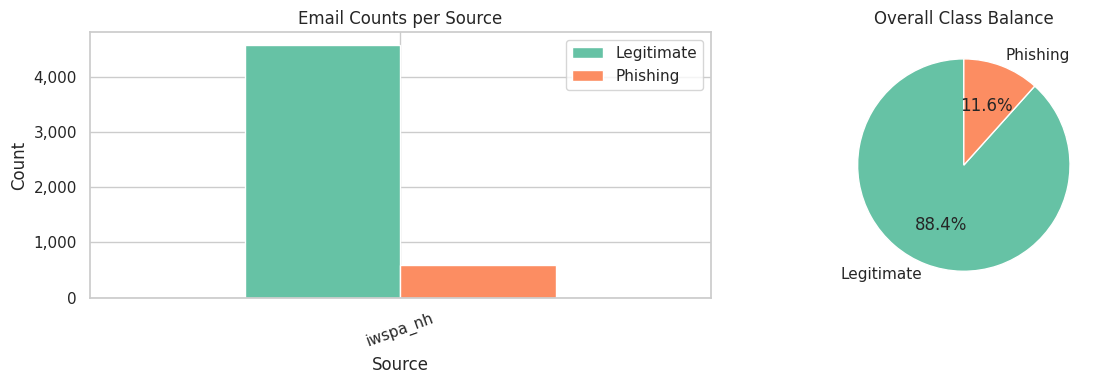

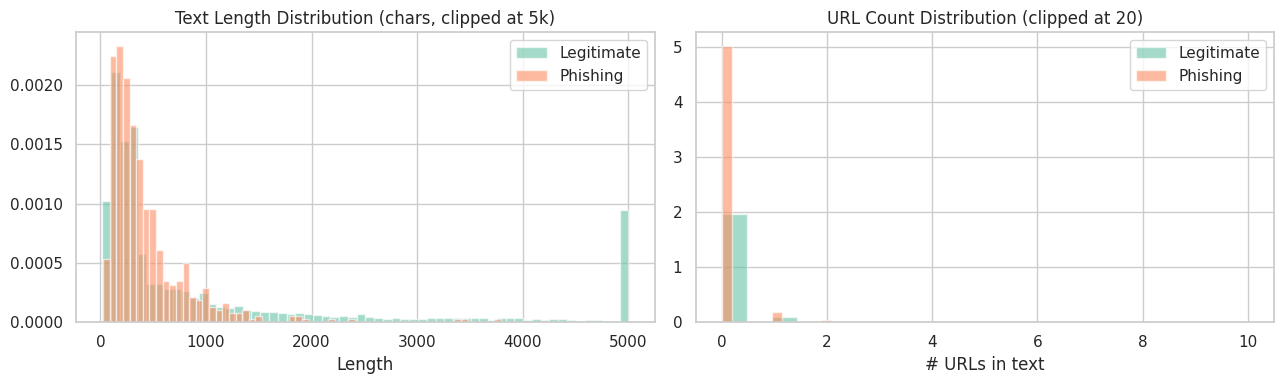

            pct_has_header  pct_has_html  avg_text_len  avg_url_count
label                                                                
Legitimate             0.0         0.344      1685.226          0.092
Phishing               0.0         0.228       426.762          0.055


In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
LABEL_NAMES = {0: "Legitimate", 1: "Phishing"}

# ── 5.1  Distribucija klasa ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Stubičasti grafikon: broj po izvoru i oznaci
pivot = df_all.groupby(["source", "label"]).size().unstack(fill_value=0)
pivot.columns = [LABEL_NAMES[c] for c in pivot.columns]
pivot.plot(kind="bar", ax=axes[0], rot=20)
axes[0].set_title("Email Counts per Source")
axes[0].set_xlabel("Source")
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Tortni grafikon: ukupna ravnoteža klasa
counts = df_all["label"].value_counts()
axes[1].pie(counts, labels=[LABEL_NAMES[i] for i in counts.index],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Overall Class Balance")

plt.tight_layout()
plt.savefig(PROC_DIR / "eda_class_distribution.png", dpi=150)
plt.show()

# ── 5.2  Distribucija dužine teksta ───────────────────────────────────────────
df_all["text_len"] = df_all["text"].str.len()

# Koristimo zasebnu EDA kolonu kako bismo izbegli prepisivanje url_count iz inženjeringa karakteristika
# Broji realne URL-ove, `www.` i IWSPA `<<link>>` placeholder-e.
df_all["eda_url_count"] = df_all["text"].str.count(r"(?i)(https?://|www\.|<<\s*link\s*>>)")

# Proveravamo body_raw (pre čišćenja) za HTML — body_clean je već očišćen pa je uvek False
df_all["has_html_flag"] = df_all["body_raw"].fillna("").str.contains(
    r"<[a-zA-Z][^>]*>", regex=True).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for lbl, grp in df_all.groupby("label"):
    axes[0].hist(grp["text_len"].clip(upper=5000), bins=60, alpha=0.6,
                 label=LABEL_NAMES[lbl], density=True)
axes[0].set_title("Text Length Distribution (chars, clipped at 5k)")
axes[0].set_xlabel("Length")
axes[0].legend()

for lbl, grp in df_all.groupby("label"):
    axes[1].hist(grp["eda_url_count"].clip(upper=20), bins=21, alpha=0.6,
                 label=LABEL_NAMES[lbl], density=True)
axes[1].set_title("URL Count Distribution (clipped at 20)")
axes[1].set_xlabel("# URLs in text")
axes[1].legend()

plt.tight_layout()
plt.savefig(PROC_DIR / "eda_length_urls.png", dpi=150)
plt.show()

# ── 5.3  Dostupnost zaglavlja i prisustvo HTML-a ───────────────────────────────
agg = df_all.groupby("label").agg(
    pct_has_header=("has_header", "mean"),
    pct_has_html  =("has_html_flag", "mean"),
    avg_text_len  =("text_len", "mean"),
    avg_url_count =("eda_url_count", "mean"),
).rename(index=LABEL_NAMES).round(3)
print(agg.to_string())

---
## Sekcija 6 — Inženjering karakteristika

Ekstrakcija **bihevioralnih / karakteristika zasnovanih na nameri** za klasične ML modele.  
Karakteristike se računaju iz `body_clean` i `text_norm`; `text_norm` (bez artefakata) je rezervisan i za TF-IDF.

| Karakteristika | Opis |
|---|---|
| `text_len` | Ukupna dužina u karakterima — zadržana kao slab signal (phishing e-mailovi su skloni opširnosti) |
| `explicit_link_count` | Broj `<URL>` tokena u `text_norm` — obuhvata https:// linkove, IWSPA `<<link>>` oznake i sve uglaste URL tokene nastale normalizacijom; neutralan prema formatima |
| `implicit_link_signal` | Binarna zastavica: 1 ako su prisutne phishing fraze sa pozivom na link (*"visit below"*, *"access here"*, *"go to the portal"*, *"use the button below"*) čak i kada nema eksplicitnog URL-a |
| `unique_word_ratio` | Raznovrsnost vokabulara (jedinstvene reči / ukupno reči) — phishing šabloni su repetitivni |
| `urgency_count` | Phishing termini pretnje: *urgent, suspended, expired, deadline, act now, final notice* … |
| `account_count` | Termini manipulacije nalogom: *verify, confirm, login, password, credentials, suspicious activity* … |
| `cta_count` | Fraze poziva na akciju: *click here, follow the link, verify now, sign in now* … |
| `threat_action_combo` | **Interakciona karakteristika** — binarno 1 kada se i signal pretnje/hitnosti I poziv na akciju pojavljuju u istom e-mailu. Klasičan phishing obrazac: *"Vaš nalog je suspendovan → kliknite ovde da ga povratite."* |

> **Uklonjene karakteristike (sa obrazloženjem):**  
> `url_count` (nepouzdan — IWSPA često koristi placeholder-e za linkove, pa sirovo brojanje URL-ova može zavesti) · `dollar_count` / `question_count` / `caps_ratio` (često korpusno-specifični stil) · `word_count` / `avg_word_len` (nizak MI, stilski signal, a ne signal namere) · `has_html` / `exclamation_count` (MI ≈ 0)

TF-IDF vektori se fituju **samo na `text_norm`** (samo na skupu za obuku) kako bi se sprečilo curenje podataka.

In [27]:
def extract_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    t        = df["text"]
    body_cl  = df["body_clean"].fillna("")
    # text_norm sadrži naše <URL>/<EMAIL>/<PHONE>/<YEAR> tokene — koristi se za
    # explicit_link_count kako bi broj bio neutralan prema skupu podataka (https://, <<link>>,
    # i svi URL tokeni u ugaonim zagradama su kolapsovani u jedan <URL> marker).
    t_norm   = df["text_norm"].fillna("")

    # ── text_len ───────────────────────────────────────────────────────────────
    df["text_len"] = t.str.len()

    # ── Raznovrsnost vokabulara ──────────────────────────────────────────────────
    def _unique_word_ratio(s: str) -> float:
        words = s.split()
        return len(set(words)) / len(words) if words else 0.0

    df["unique_word_ratio"] = t.apply(_unique_word_ratio)

    # ── Karakteristike prisustva linkova ───────────────────────────────────────
    # explicit_link_count: broji <URL> tokene u text_norm.
    # normalize_text() objedinjuje sve: https:// URL-ove, IWSPA <<link>> oznake,
    # i URL tokene u ugaonim zagradama u jedan "<URL>" marker, pa je ovaj broj
    # stabilan i neutralan prema skupu podataka.
    df["explicit_link_count"] = t_norm.str.count("<URL>")

    # implicit_link_signal: binarna zastavica za phishing fraze koje pozivaju na praćenje linka,
    # koje impliciraju "prati link" čak i kada nema eksplicitnog URL-a.
    # Namerno odvojeno od cta_count ("click here") radi hvatanja mekših oblika.
    _IMPLICIT_LINK_RE = re.compile(
        r"\b(visit\s+(below|here|us|our|the\s+(link|page|site|url))|"
        r"access\s+(here|below|the\s+(link|page|account|portal))|"
        r"go\s+to\s+(the\s+)?(link|page|site|portal|url)|"
        r"use\s+the\s+(link|url|button)\s+below|"
        r"follow\s+the\s+(link|url|instructions)\s+below|"
        r"tap\s+(here|the\s+link|below))\b",
        re.IGNORECASE,
    )
    df["implicit_link_signal"] = body_cl.apply(
        lambda s: int(bool(_IMPLICIT_LINK_RE.search(s)))
    )

    # ── Bihevioralni signali phishinga ─────────────────────────────────────────
    _URGENCY_RE = re.compile(
        r"\b(urgent|urgently|immediately|action\s+required|suspended|"
        r"locked\s+out|your\s+account\s+(has\s+been|is|will\s+be)|"
        r"expire[sd]?|expiration|deadline|attention|alert|warning|"
        r"act\s+now|final\s+notice|last\s+chance)\b",
        re.IGNORECASE,
    )
    _ACCOUNT_RE = re.compile(
        r"\b(verify|verification|confirm(?:ation)?|update\s+your|"
        r"log\s*in|login|password|credentials|secure\s+your|"
        r"security\s+alert|authenticate|suspicious\s+(activity|login|access)|"
        r"account\s+(verify|confirm|update|suspend|access|number))\b",
        re.IGNORECASE,
    )
    _CTA_RE = re.compile(
        r"\b(click\s+here|click\s+below|click\s+the\s+link|follow\s+the\s+link|"
        r"confirm\s+your\s+identity|verify\s+now|verify\s+your|"
        r"sign\s+in\s+now|log\s+in\s+now|open\s+the\s+link)\b",
        re.IGNORECASE,
    )

    df["urgency_count"] = body_cl.apply(lambda s: len(_URGENCY_RE.findall(s)))
    df["account_count"] = body_cl.apply(lambda s: len(_ACCOUNT_RE.findall(s)))
    df["cta_count"]     = body_cl.apply(lambda s: len(_CTA_RE.findall(s)))

    # ── Interakciona karakteristika ──────────────────────────────────────────────
    # threat_action_combo: 1 kada se I signal pretnje/hitnosti I CTA pojavljuju zajedno.
    # Klasični phishing obrazac: "Vaš nalog je suspendovan → kliknite ovde da ga povratite."
    df["threat_action_combo"] = (
        ((df["urgency_count"] > 0) | (df["account_count"] > 0)) &
        (df["cta_count"] > 0)
    ).astype(int)

    return df


print("Extracting features ...")
df_all = extract_features(df_all)

FEATURE_COLS = [
    "text_len",
    "explicit_link_count",
    "implicit_link_signal",
    "unique_word_ratio",
    "urgency_count",
    "account_count",
    "cta_count",
    "threat_action_combo",
]

LABEL_NAMES = {0: "Legitimate", 1: "Phishing"}

print(df_all[FEATURE_COLS + ["label"]].groupby("label").mean()
      .rename(index=LABEL_NAMES).round(3).to_string())

Extracting features ...
            text_len  explicit_link_count  implicit_link_signal  unique_word_ratio  urgency_count  account_count  cta_count  threat_action_combo
label                                                                                                                                           
Legitimate  1685.226                0.091                 0.003              0.802          0.138          0.065      0.062                0.010
Phishing     426.762                0.055                 0.048              0.819          0.422          0.799      0.382                0.201


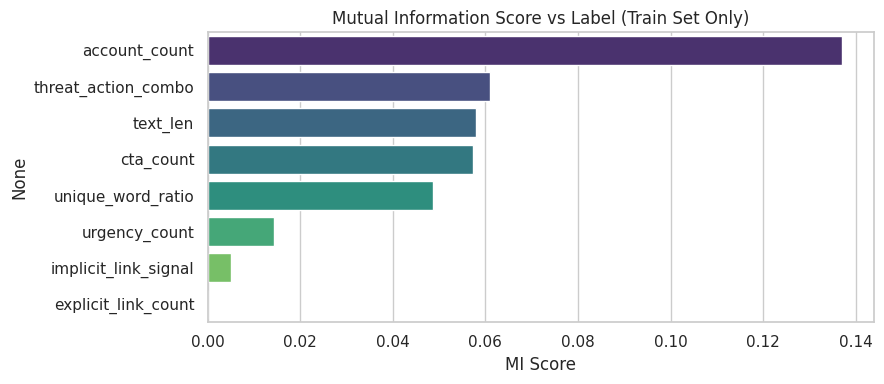

Mutual Information (computed on train set only - no test leakage):
account_count           0.137064
threat_action_combo     0.060981
text_len                0.057987
cta_count               0.057404
unique_word_ratio       0.048728
urgency_count           0.014307
implicit_link_signal    0.004967
explicit_link_count     0.000000


In [28]:
from sklearn.feature_selection import mutual_info_classif

# ── CRITICAL: Compute MI on TRAIN set ONLY (post-split) to avoid test leakage ──
X_feat_train = df_train[FEATURE_COLS].fillna(0).values
y_train_mi   = df_train["label"].values

mi_scores = mutual_info_classif(X_feat_train, y_train_mi, random_state=42)
mi_df = pd.Series(mi_scores, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(9, 4))
sns.barplot(x=mi_df.values, y=mi_df.index, palette="viridis")
plt.title("Mutual Information Score vs Label (Train Set Only)")
plt.xlabel("MI Score")
plt.tight_layout()
plt.savefig(PROC_DIR / "feature_importance_mi.png", dpi=150)
plt.show()
print("Mutual Information (computed on train set only - no test leakage):")
print(mi_df.to_string())

---
## Sekcija 7 — Podela na skup za obuku i testiranje

**Rukovanje neravnotežom:** IWSPA je i dalje neuravnotežen skup (legitimni dominiraju).  
Zadržavamo **sve phishing** e-mailove i **smanjujemo uzorak legitimnih na 2:1** (legitimate:phishing).

Stratifikovana podela 80/20 na balansiranom skupu, serijalizovana u CSV za ponovnu upotrebu u ćelijama modela.

In [29]:
from sklearn.model_selection import train_test_split

SAVE_COLS = ["text", "text_norm", "subject_clean", "body_clean",
             "has_header", "source", "label"] + FEATURE_COLS

# ── Smanjivanje uzorka legitimnih e-mailova radi balansa ───────────────────────
# Strategija: zadržavamo SVE phishing, smanjujemo uzorak legitimnih na TARGET_RATIO:1
TARGET_RATIO = 2    # legitimate:phishing

n_phish = (df_all["label"] == 1).sum()
n_legit = (df_all["label"] == 0).sum()

if n_phish == 0 or n_legit == 0:
    raise ValueError(
        f"Dataset must contain both classes (legit={n_legit}, phish={n_phish})."
    )

n_legit_target = min(n_legit, n_phish * TARGET_RATIO)

df_phish = df_all[df_all["label"] == 1]
df_legit = df_all[df_all["label"] == 0]

# Smanjivanje legitimnih (robustno: stratify samo ako ima više izvora)
if n_legit_target == len(df_legit):
    df_legit_under = df_legit
else:
    if df_legit["source"].nunique() > 1:
        df_legit_under, _ = train_test_split(
            df_legit,
            train_size=n_legit_target,
            stratify=df_legit["source"],
            random_state=42,
        )
    else:
        df_legit_under = df_legit.sample(n=n_legit_target, random_state=42)

df_balanced = pd.concat([df_legit_under, df_phish], ignore_index=True) \
                .sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Before undersampling : {len(df_all):,} emails  "
      f"(ratio {(df_all.label==0).sum()/(df_all.label==1).sum():.1f}:1)")
print(f"After  undersampling : {len(df_balanced):,} emails  "
      f"(ratio {(df_balanced.label==0).sum()/(df_balanced.label==1).sum():.1f}:1)")
print()
print(df_balanced.groupby(["source", "label"]).size().unstack(fill_value=0).rename(
    columns={0: "legitimate", 1: "phishing"}).to_string())
print()

# ── Stratifikovana podela 60/20/20 (train/validation/test) ──────────────────────
# CRITICAL: test set is LOCKED after this split and never touched until final evaluation (Sec 12)
# Validation set is used ONLY for hard-case identification (Sec 10); NOT used in k-fold CV

# First split: 80% train/val, 20% test (locked)
df_temp, df_test = train_test_split(
    df_balanced[SAVE_COLS],
    test_size=0.2,
    random_state=42,
    stratify=df_balanced["label"],
)

# Second split: of 80%, split into 75% train, 25% validation → 60% train, 20% validation
df_train, df_val = train_test_split(
    df_temp,
    test_size=0.25,  # 25% of 80% = 20% of total
    random_state=42,
    stratify=df_temp["label"],
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Train : {len(df_train):,}  (phishing={df_train.label.sum():,}, "
      f"{df_train.label.mean()*100:.1f}%)  [60% of data]")
print(f"Val   : {len(df_val):,}  (phishing={df_val.label.sum():,}, "
      f"{df_val.label.mean()*100:.1f}%)  [20% of data - hard-case discovery only]")
print(f"Test  : {len(df_test):,}  (phishing={df_test.label.sum():,}, "
      f"{df_test.label.mean()*100:.1f}%)  [20% of data - LOCKED until final eval]")

df_train.to_csv(PROC_DIR / "train.csv", index=False)
df_val.to_csv(PROC_DIR   / "val.csv", index=False)
df_test.to_csv(PROC_DIR  / "test.csv",  index=False)
df_balanced[SAVE_COLS].to_csv(PROC_DIR / "full_dataset.csv", index=False)
print("\nSaved to:", PROC_DIR)
print("\n⚠️  TEST SET IS NOW LOCKED - DO NOT USE UNTIL SECTION 12")

Before undersampling : 5,172 emails  (ratio 7.6:1)
After  undersampling : 1,806 emails  (ratio 2.0:1)

label     legitimate  phishing
source                        
iwspa_nh        1204       602

Train : 1,083  (phishing=361, 33.3%)  [60% of data]
Val   : 361  (phishing=120, 33.2%)  [20% of data - hard-case discovery only]
Test  : 362  (phishing=121, 33.4%)  [20% of data - LOCKED until final eval]

Saved to: data/processed

⚠️  TEST SET IS NOW LOCKED - DO NOT USE UNTIL SECTION 12


---
## Sekcija 8 — Osnova: Klasični ML modeli (Random Forest i XGBoost)

Karakteristike: strukturne karakteristike + TF-IDF (fitovan **samo na skupu za obuku** radi sprečavanja curenja podataka)

In [30]:
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report, roc_auc_score, f1_score,
                              ConfusionMatrixDisplay, RocCurveDisplay)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed – skipping XGBoost model")

# ── Izgradnja matrica karakteristika (train + test sets) ──────────────────────────
# Koristimo text_norm za TF-IDF — neutrališe vokabular specifičan za skup podataka,
# pa model uči phishing SIGNALE, a ne tokene specifične za korpus.
X_train_text = df_train["text_norm"]
X_test_text  = df_test["text_norm"]
y_train_full = df_train["label"].values
y_test_full  = df_test["label"].values

# TF-IDF se fituje samo na skupu za obuku (sprečava i curenje podataka i curenje izvora)
tfidf = TfidfVectorizer(max_features=20_000, sublinear_tf=True,
                         ngram_range=(1, 2), min_df=3)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

# Strukturne karakteristike
X_train_struct = csr_matrix(df_train[FEATURE_COLS].fillna(0).values)
X_test_struct  = csr_matrix(df_test[FEATURE_COLS].fillna(0).values)

# Kombinovane
X_train_combined = hstack([X_train_tfidf, X_train_struct])
X_test_combined  = hstack([X_test_tfidf,  X_test_struct])

print(f"Combined train shape: {X_train_combined.shape}")
print(f"Combined test  shape: {X_test_combined.shape}")

Combined train shape: (1083, 13304)
Combined test  shape: (362, 13304)


In [31]:
# ════════════════════════════════════════════════════════════════════════════════
# K-FOLD CROSS-VALIDATION ON TRAIN SET (DIAGNOSTIC METRICS ONLY)
# Final evaluation will be done on fixed test set (Sec 12)
# ════════════════════════════════════════════════════════════════════════════════

def train_and_evaluate_fold(name, model_class, model_params, X_train, y_train,
                             fold_id, X_test=None, y_test=None):
    """Train model on fold and return predictions + metrics."""
    model = model_class(**model_params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_train)
    y_proba = model.predict_proba(X_train)[:, 1]

    f1 = f1_score(y_train, y_pred, pos_label=1, zero_division=0)
    auc = roc_auc_score(y_train, y_proba)

    return {
        "model": model,
        "f1": f1,
        "auc": auc,
        "y_pred": y_pred,
        "y_proba": y_proba,
    }

# ── K-Fold setup ────────────────────────────────────────────────────────────────
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# ──────────────────────────────────────────────────────────────────────────────────
# RANDOM FOREST - K-Fold Cross-Validation (Diagnostic)
# ──────────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("RANDOM FOREST - K-FOLD CROSS-VALIDATION (Diagnostic Metrics)")
print("="*70)

rf_fold_results = []
for fold_id, (train_idx, val_idx) in enumerate(skf.split(X_train_combined, y_train_full)):
    X_fold_train = X_train_combined[train_idx]
    y_fold_train = y_train_full[train_idx]

    fold_result = train_and_evaluate_fold(
        "RF", RandomForestClassifier,
        {"n_estimators": 300, "n_jobs": -1, "random_state": 42, "class_weight": "balanced"},
        X_fold_train, y_fold_train, fold_id
    )
    rf_fold_results.append(fold_result)
    print(f"  Fold {fold_id+1}/{N_SPLITS}: F1={fold_result['f1']:.4f}, AUC={fold_result['auc']:.4f}")

rf_cv_f1_mean = np.mean([r["f1"] for r in rf_fold_results])
rf_cv_f1_std = np.std([r["f1"] for r in rf_fold_results])
rf_cv_auc_mean = np.mean([r["auc"] for r in rf_fold_results])
rf_cv_auc_std = np.std([r["auc"] for r in rf_fold_results])

print(f"  Mean F1  : {rf_cv_f1_mean:.4f} ± {rf_cv_f1_std:.4f}")
print(f"  Mean AUC : {rf_cv_auc_mean:.4f} ± {rf_cv_auc_std:.4f}")

# ──────────────────────────────────────────────────────────────────────────────────
# XGBOOST - K-Fold Cross-Validation (Diagnostic)
# ──────────────────────────────────────────────────────────────────────────────────
xgb_fold_results = []
if HAS_XGB:
    print("\n" + "="*70)
    print("XGBOOST - K-FOLD CROSS-VALIDATION (Diagnostic Metrics)")
    print("="*70)

    scale_pw = (y_train_full == 0).sum() / (y_train_full == 1).sum()

    for fold_id, (train_idx, val_idx) in enumerate(skf.split(X_train_combined, y_train_full)):
        X_fold_train = X_train_combined[train_idx]
        y_fold_train = y_train_full[train_idx]

        fold_result = train_and_evaluate_fold(
            "XGB", XGBClassifier,
            {"n_estimators": 300, "learning_rate": 0.1, "max_depth": 6,
             "scale_pos_weight": scale_pw, "eval_metric": "logloss",
             "random_state": 42, "n_jobs": -1, "verbosity": 0},
            X_fold_train, y_fold_train, fold_id
        )
        xgb_fold_results.append(fold_result)
        print(f"  Fold {fold_id+1}/{N_SPLITS}: F1={fold_result['f1']:.4f}, AUC={fold_result['auc']:.4f}")

    xgb_cv_f1_mean = np.mean([r["f1"] for r in xgb_fold_results])
    xgb_cv_f1_std = np.std([r["f1"] for r in xgb_fold_results])
    xgb_cv_auc_mean = np.mean([r["auc"] for r in xgb_fold_results])
    xgb_cv_auc_std = np.std([r["auc"] for r in xgb_fold_results])

    print(f"  Mean F1  : {xgb_cv_f1_mean:.4f} ± {xgb_cv_f1_std:.4f}")
    print(f"  Mean AUC : {xgb_cv_auc_mean:.4f} ± {xgb_cv_auc_std:.4f}")

print("\n✓ K-fold diagnostic metrics complete. Final models trained on full train set in next step.")


RANDOM FOREST - K-FOLD CROSS-VALIDATION (Diagnostic Metrics)
  Fold 1/5: F1=1.0000, AUC=1.0000
  Fold 2/5: F1=1.0000, AUC=1.0000
  Fold 3/5: F1=1.0000, AUC=1.0000
  Fold 4/5: F1=1.0000, AUC=1.0000
  Fold 5/5: F1=1.0000, AUC=1.0000
  Mean F1  : 1.0000 ± 0.0000
  Mean AUC : 1.0000 ± 0.0000

XGBOOST - K-FOLD CROSS-VALIDATION (Diagnostic Metrics)
  Fold 1/5: F1=1.0000, AUC=1.0000
  Fold 2/5: F1=1.0000, AUC=1.0000
  Fold 3/5: F1=1.0000, AUC=1.0000
  Fold 4/5: F1=1.0000, AUC=1.0000
  Fold 5/5: F1=1.0000, AUC=1.0000
  Mean F1  : 1.0000 ± 0.0000
  Mean AUC : 1.0000 ± 0.0000

✓ K-fold diagnostic metrics complete. Final models trained on full train set in next step.



FINAL MODELS: Training on Full Train Set for Test Evaluation
✓ Final Random Forest trained on full train set
✓ Final XGBoost trained on full train set


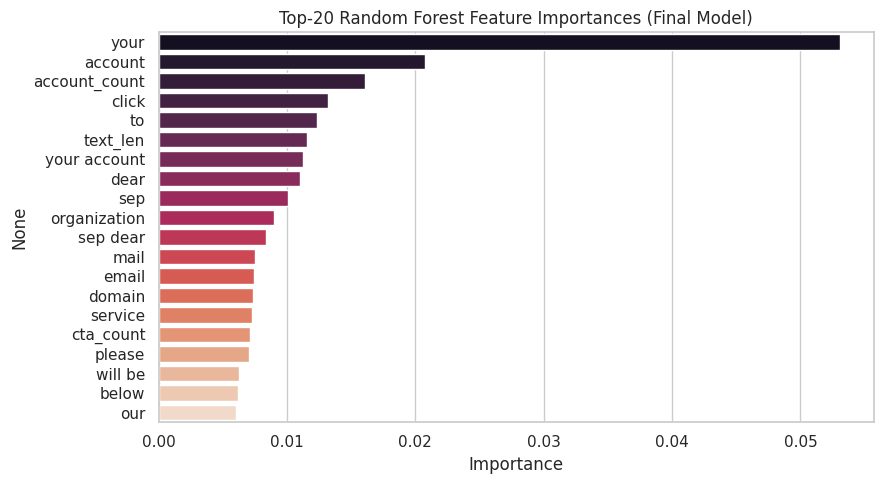

In [32]:
# ════════════════════════════════════════════════════════════════════════════════
# FINAL MODELS: Train on ALL of df_train, test on FIXED df_test
# (These are the models used for final comparison in Section 12)
# ════════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("FINAL MODELS: Training on Full Train Set for Test Evaluation")
print("="*70)

# Train final Random Forest on 100% of training data
rf_final = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42,
                                  class_weight="balanced")
rf_final.fit(X_train_combined, y_train_full)
rf_pred_test = rf_final.predict(X_test_combined)
rf_proba_test = rf_final.predict_proba(X_test_combined)[:, 1]
print("✓ Final Random Forest trained on full train set")

# Train final XGBoost on 100% of training data
if HAS_XGB:
    scale_pw = (y_train_full == 0).sum() / (y_train_full == 1).sum()
    xgb_final = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                              scale_pos_weight=scale_pw, eval_metric="logloss",
                              random_state=42, n_jobs=-1, verbosity=0)
    xgb_final.fit(X_train_combined, y_train_full)
    xgb_pred_test = xgb_final.predict(X_test_combined)
    xgb_proba_test = xgb_final.predict_proba(X_test_combined)[:, 1]
    print("✓ Final XGBoost trained on full train set")

# Feature importance from final Random Forest
feat_names = tfidf.get_feature_names_out().tolist() + FEATURE_COLS
importances = pd.Series(rf_final.feature_importances_, index=feat_names)
top20 = importances.nlargest(20)

plt.figure(figsize=(9, 5))
sns.barplot(x=top20.values, y=top20.index, palette="rocket")
plt.title("Top-20 Random Forest Feature Importances (Final Model)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(PROC_DIR / "rf_feature_importances.png", dpi=150)
plt.show()

---
## Sekcija 9 — GPT referentni model bez fino podešavanja (zero-shot)

> **⚠️ Zahteva OpenAI API ključ.**  
> Postavite `OPENAI_API_KEY` u okruženju ili ga unesite ispod.  
> Radi kontrole troškova, GPT se pokreće samo na **testnom skupu** (ili uzorku iz njega).

Prompt traži od modela da vrati `0` (legitimni) ili `1` (phishing).

In [33]:
import os, time, json

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GPT_MODEL      = "gpt-4o-mini"

SYSTEM_PROMPT = (
    "You are a cybersecurity expert. Classify the email below as phishing (1) or "
    "legitimate (0). Reply with ONLY the integer 0 or 1, nothing else."
)

def classify_gpt(text: str, client) -> int:
    """Poziva GPT zero-shot i vraća 0 ili 1."""
    try:
        resp = client.chat.completions.create(
            model=GPT_MODEL,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": text[:3000]},
            ],
            max_tokens=5,
            temperature=0,
        )
        ans = resp.choices[0].message.content.strip()
        return int(ans) if ans in ("0", "1") else -1
    except Exception as e:
        print(f"  API error: {e}")
        time.sleep(2)
        return -1


# ── CRITICAL: Run GPT on FULL TEST SET (not subsample) for fair model comparison ──
if OPENAI_API_KEY:
    from openai import OpenAI
    client = OpenAI(api_key=OPENAI_API_KEY)

    print("="*70)
    print("GPT-4o-mini INFERENCE ON FULL TEST SET")
    print("="*70)

    # Run GPT on entire test set (for final comparison in Sec 12)
    df_gpt_test = df_test.copy()
    gpt_test_preds = []

    print(f"Running GPT on {len(df_gpt_test):,} test emails "
          f"({(df_gpt_test.label==0).sum()} legit, {(df_gpt_test.label==1).sum()} phish) ...")

    for _, row in tqdm(df_gpt_test.iterrows(), total=len(df_gpt_test), desc="GPT inference"):
        gpt_test_preds.append(classify_gpt(row["text"], client))

    df_gpt_test["gpt_pred"] = gpt_test_preds
    df_gpt_test = df_gpt_test[df_gpt_test["gpt_pred"] != -1].reset_index(drop=True)

    gpt_test_auc = roc_auc_score(df_gpt_test["label"], df_gpt_test["gpt_pred"])
    print(f"✓ GPT-4o-mini on test set (n={len(df_gpt_test):,}, ROC-AUC={gpt_test_auc:.4f})")

    df_gpt_test.to_csv(PROC_DIR / "gpt_predictions_test.csv", index=False)

    # Also run GPT on validation set to identify hard cases
    print("\n" + "="*70)
    print("GPT-4o-mini INFERENCE ON VALIDATION SET (for hard-case discovery)")
    print("="*70)

    df_gpt_val = df_val.copy()
    gpt_val_preds = []

    print(f"Running GPT on {len(df_gpt_val):,} validation emails "
          f"({(df_gpt_val.label==0).sum()} legit, {(df_gpt_val.label==1).sum()} phish) ...")

    for _, row in tqdm(df_gpt_val.iterrows(), total=len(df_gpt_val), desc="GPT inference (val)"):
        gpt_val_preds.append(classify_gpt(row["text"], client))

    df_gpt_val["gpt_pred"] = gpt_val_preds
    df_gpt_val = df_gpt_val[df_gpt_val["gpt_pred"] != -1].reset_index(drop=True)

    gpt_val_auc = roc_auc_score(df_gpt_val["label"], df_gpt_val["gpt_pred"])
    print(f"✓ GPT-4o-mini on validation set (n={len(df_gpt_val):,}, ROC-AUC={gpt_val_auc:.4f})")

    df_gpt_val.to_csv(PROC_DIR / "gpt_predictions_val.csv", index=False)

else:
    print("No API key – loading saved GPT predictions (if available) ...")
    gpt_test_path = PROC_DIR / "gpt_predictions_test.csv"
    gpt_val_path = PROC_DIR / "gpt_predictions_val.csv"

    if gpt_test_path.exists():
        df_gpt_test = pd.read_csv(gpt_test_path)
        print(f"✓ Loaded {len(df_gpt_test):,} GPT test predictions")
    else:
        print("No saved test predictions found. Set OPENAI_API_KEY to run GPT inference.")
        df_gpt_test = None

    if gpt_val_path.exists():
        df_gpt_val = pd.read_csv(gpt_val_path)
        print(f"✓ Loaded {len(df_gpt_val):,} GPT validation predictions")
    else:
        print("No saved validation predictions found. Set OPENAI_API_KEY to run GPT inference.")
        df_gpt_val = None

GPT-4o-mini INFERENCE ON FULL TEST SET
Running GPT on 362 test emails (241 legit, 121 phish) ...


GPT inference:   0%|          | 0/362 [00:00<?, ?it/s]

✓ GPT-4o-mini on test set (n=362, ROC-AUC=0.8217)

GPT-4o-mini INFERENCE ON VALIDATION SET (for hard-case discovery)
Running GPT on 361 validation emails (241 legit, 120 phish) ...


GPT inference (val):   0%|          | 0/361 [00:00<?, ?it/s]

✓ GPT-4o-mini on validation set (n=361, ROC-AUC=0.8380)


---
## Sekcija 10 — Analiza grešaka GPT-a

Identifikacija **lažnih pozitiva** (legitimni → predviđen kao phishing) i **lažnih negativa** (phishing → predviđen kao legitimni).  
Grupisanje po zajedničkim obrascima radi usmeravanja fino podešavanja BERT-a.

In [34]:
# ════════════════════════════════════════════════════════════════════════════════
# HARD-CASE IDENTIFICATION FROM VALIDATION SET
# (NOT from test set - validation is separate and safe for hard-case discovery)
# ════════════════════════════════════════════════════════════════════════════════

if "df_gpt_val" in dir() and df_gpt_val is not None and "gpt_pred" in df_gpt_val.columns:
    print("="*70)
    print("HARD-CASE ANALYSIS (From Validation Set GPT Predictions)")
    print("="*70)

    fp_df = df_gpt_val[(df_gpt_val["label"] == 0) & (df_gpt_val["gpt_pred"] == 1)].copy()
    fn_df = df_gpt_val[(df_gpt_val["label"] == 1) & (df_gpt_val["gpt_pred"] == 0)].copy()

    print(f"\nFalse Positives (legit → predicted phishing) : {len(fp_df):,}")
    print(f"False Negatives (phishing → predicted legit) : {len(fn_df):,}")

    # Kratka analiza obrazaca: broj URL-ova, dužina teksta, distribucija izvora
    for name, subset in [("False Positives", fp_df), ("False Negatives", fn_df)]:
        if len(subset) > 0:
            print(f"\n── {name} ──")
            print(subset[["source"] + FEATURE_COLS].describe().T[["mean", "std", "min", "max"]].round(2).to_string())
            print("\nSource breakdown:")
            print(subset["source"].value_counts().to_string())
            print("\nSample texts:")
            for _, row in subset.head(3).iterrows():
                print(f"  [{row['source']}] {row['text'][:200]}\n")

    # Čuvamo teške slučajeve za naglasak pri fino podešavanju BERT-a
    # CRITICAL: These hard cases come from VALIDATION set, NOT test set
    hard_cases = pd.concat([fp_df, fn_df]).drop_duplicates()
    hard_cases["is_hard"] = 1
    hard_cases.to_csv(PROC_DIR / "gpt_hard_cases_from_val.csv", index=False)
    print(f"\n✓ Saved {len(hard_cases):,} hard cases from VALIDATION set to gpt_hard_cases_from_val.csv")
    print("  These cases will be used for BERT training upsampling (problem 6 fix)")
else:
    print("GPT validation predictions not available – run Section 9 first.")

HARD-CASE ANALYSIS (From Validation Set GPT Predictions)

False Positives (legit → predicted phishing) : 60
False Negatives (phishing → predicted legit) : 9

── False Positives ──
                         mean      std    min     max
text_len              1585.95  2094.90  31.00  9721.0
explicit_link_count      0.27     0.80   0.00     4.0
implicit_link_signal     0.00     0.00   0.00     0.0
unique_word_ratio        0.80     0.17   0.45     1.0
urgency_count            0.03     0.18   0.00     1.0
account_count            0.00     0.00   0.00     0.0
cta_count                0.10     0.35   0.00     2.0
threat_action_combo      0.00     0.00   0.00     0.0

Source breakdown:
source
iwspa_nh    60

Sample texts:
  [iwspa_nh]  [SEP] colin,
i thought that this didn't happen.

  [iwspa_nh]  [SEP] view this email in your browser ������� power plays����� the burwell vs. hobby lobby stores, inc. case, which was narrowly decided by the u.s. supreme court, has led to a lot of controversy. � 



---
## Sekcija 11 — Fino podešavanje BERT-a za binarnu klasifikaciju

> **Napomena o hardveru:** Pokretanje na CPU (AMD Ryzen 7 PRO 8840U, integrisani Radeon 780M — nema CUDA/ROCm).  
> Koristimo **DistilBERT** (`distilbert-base-uncased`) umesto BERT-base:  
> - ~60 M parametara naspram 110 M → ~2× brže zaključivanje i obuka  
> - U okviru 3% od tačnosti BERT-a na većini zadataka klasifikacije  
> - `MAX_LEN=128`, `BATCH_SZ=32`, `EPOCHS=2`, obuka ograničena na **10 000 uzoraka** → ~10–15 min na CPU  

Strategija:
- Bazni model: `distilbert-base-uncased`
- Teški slučajevi identifikovani u Sekciji 10 su **povećani uzorkovanjem** (×3) pre ograničenja
- Glava za binarnu sekvencijalnu klasifikaciju
- AdamW + linearni raspored zagrevanja

In [35]:
try:
    import torch
    from torch.utils.data import Dataset, DataLoader
    from transformers import (
        DistilBertTokenizerFast, DistilBertForSequenceClassification,
        get_linear_schedule_with_warmup,
    )
    from torch.optim import AdamW
    from sklearn.metrics import f1_score
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False
    print("PyTorch / Transformers not installed. Skipping BERT section.")

if HAS_TORCH:
    # ── Hiper-parametri prilagođeni CPU-u ──────────────────────────────────────
    BERT_MODEL_NAME = "distilbert-base-uncased"
    MAX_LEN          = 128
    BATCH_SZ         = 32
    EPOCHS           = 2
    LR               = 3e-5
    MAX_TRAIN_SAMPLES = 10_000
    N_SPLITS_BERT = 5
    DEVICE = torch.device("cpu")

    print(f"Device: {DEVICE}")
    print(f"Model : {BERT_MODEL_NAME}  |  MAX_LEN={MAX_LEN}  |  EPOCHS={EPOCHS}  |  cap={MAX_TRAIN_SAMPLES:,}")

    tokenizer = DistilBertTokenizerFast.from_pretrained(BERT_MODEL_NAME)

    class EmailDataset(Dataset):
        def __init__(self, texts, labels, tokenizer, max_len):
            self.enc = tokenizer(
                texts.tolist(), truncation=True, padding="max_length",
                max_length=max_len, return_tensors="pt",
            )
            self.labels = torch.tensor(labels, dtype=torch.long)

        def __len__(self):
            return len(self.labels)

        def __getitem__(self, idx):
            return {
                "input_ids":      self.enc["input_ids"][idx],
                "attention_mask": self.enc["attention_mask"][idx],
                "labels":         self.labels[idx],
            }

    # ════════════════════════════════════════════════════════════════════════════════
    # K-FOLD CROSS-VALIDATION ON TRAIN SET (DIAGNOSTIC METRICS)
    # Hard cases from validation set are upsampled INTO each fold
    # ════════════════════════════════════════════════════════════════════════════════

    print("\n" + "="*70)
    print("DISTILBERT - K-FOLD CROSS-VALIDATION (Diagnostic Metrics)")
    print("="*70)

    # Load hard cases from validation set (identified in Sec 10)
    hard_path = PROC_DIR / "gpt_hard_cases_from_val.csv"
    if hard_path.exists():
        hard_df = pd.read_csv(hard_path)[["text", "label"]]
        print(f"Loaded {len(hard_df):,} hard cases from validation set")
        print(f"  (will be upsampled ×3 and mixed into each fold)")
    else:
        hard_df = pd.DataFrame(columns=["text", "label"])
        print("No hard cases file found - will train on standard train set")

    # ── K-Fold setup ────────────────────────────────────────────────────────────
    skf_bert = StratifiedKFold(n_splits=N_SPLITS_BERT, shuffle=True, random_state=42)

    bert_fold_results = []

    for fold_id, (train_idx, val_idx) in enumerate(skf_bert.split(df_train, df_train["label"])):
        print(f"\n  Fold {fold_id+1}/{N_SPLITS_BERT}")

        # Get fold data
        df_fold_train_only = df_train.iloc[train_idx][["text", "label"]].copy()
        df_fold_val = df_train.iloc[val_idx][["text", "label"]].copy()

        # Upsample hard cases into this fold's training data
        if len(hard_df) > 0:
            df_fold_train = pd.concat(
                [df_fold_train_only] + [hard_df] * 3,
                ignore_index=True,
            )
        else:
            df_fold_train = df_fold_train_only

        # Stratified sampling to MAX_TRAIN_SAMPLES if needed
        if len(df_fold_train) > MAX_TRAIN_SAMPLES:
            from sklearn.model_selection import train_test_split as _tts
            df_fold_train, _ = _tts(
                df_fold_train, train_size=MAX_TRAIN_SAMPLES,
                stratify=df_fold_train["label"], random_state=42,
            )

        df_fold_train = df_fold_train.sample(frac=1, random_state=42).reset_index(drop=True)

        # Create datasets
        train_ds_fold = EmailDataset(df_fold_train["text"], df_fold_train["label"].values,
                                     tokenizer, MAX_LEN)
        val_ds_fold = EmailDataset(df_fold_val["text"], df_fold_val["label"].values,
                                   tokenizer, MAX_LEN)

        train_loader_fold = DataLoader(train_ds_fold, batch_size=BATCH_SZ, shuffle=True,
                                       num_workers=0)
        val_loader_fold = DataLoader(val_ds_fold, batch_size=BATCH_SZ * 2, num_workers=0)

        # Initialize fresh model for this fold
        model_fold = DistilBertForSequenceClassification.from_pretrained(
            BERT_MODEL_NAME, num_labels=2
        ).to(DEVICE)

        optimizer_fold = AdamW(model_fold.parameters(), lr=LR, weight_decay=0.01)
        total_steps_fold = len(train_loader_fold) * EPOCHS
        scheduler_fold = get_linear_schedule_with_warmup(
            optimizer_fold, num_warmup_steps=max(1, total_steps_fold // 10),
            num_training_steps=total_steps_fold,
        )

        # Training loop for this fold
        best_f1 = 0.0
        for epoch in range(1, EPOCHS + 1):
            model_fold.train()
            total_loss = 0
            for batch in tqdm(train_loader_fold, desc=f"    Epoch {epoch}/{EPOCHS}", leave=False):
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                out = model_fold(**batch)
                loss = out.loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model_fold.parameters(), 1.0)
                optimizer_fold.step()
                scheduler_fold.step()
                optimizer_fold.zero_grad()
                total_loss += loss.item()

            avg_loss = total_loss / len(train_loader_fold)

            # Fold validation
            model_fold.eval()
            fold_preds, fold_labels = [], []
            with torch.no_grad():
                for batch in val_loader_fold:
                    batch = {k: v.to(DEVICE) for k, v in batch.items()}
                    logits = model_fold(**batch).logits
                    preds = logits.argmax(dim=-1).cpu().numpy()
                    fold_preds.extend(preds)
                    fold_labels.extend(batch["labels"].cpu().numpy())

            fold_f1 = f1_score(fold_labels, fold_preds, pos_label=1, zero_division=0)
            fold_auc = roc_auc_score(fold_labels, fold_preds)

            if fold_f1 > best_f1:
                best_f1 = fold_f1

        print(f"    Best F1: {best_f1:.4f}, AUC: {fold_auc:.4f}")
        bert_fold_results.append({"f1": fold_f1, "auc": fold_auc})

    bert_cv_f1_mean = np.mean([r["f1"] for r in bert_fold_results])
    bert_cv_f1_std = np.std([r["f1"] for r in bert_fold_results])
    bert_cv_auc_mean = np.mean([r["auc"] for r in bert_fold_results])
    bert_cv_auc_std = np.std([r["auc"] for r in bert_fold_results])

    print(f"\n  Mean F1  : {bert_cv_f1_mean:.4f} ± {bert_cv_f1_std:.4f}")
    print(f"  Mean AUC : {bert_cv_auc_mean:.4f} ± {bert_cv_auc_std:.4f}")

    print("\n✓ K-fold diagnostic metrics complete. Final BERT model trained on full train set in next step.")


Device: cpu
Model : distilbert-base-uncased  |  MAX_LEN=128  |  EPOCHS=2  |  cap=10,000

DISTILBERT - K-FOLD CROSS-VALIDATION (Diagnostic Metrics)
Loaded 69 hard cases from validation set
  (will be upsampled ×3 and mixed into each fold)

  Fold 1/5


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    Epoch 1/2:   0%|          | 0/34 [00:00<?, ?it/s]

    Epoch 2/2:   0%|          | 0/34 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    Epoch 1/2:   0%|          | 0/34 [00:00<?, ?it/s]

    Epoch 2/2:   0%|          | 0/34 [00:00<?, ?it/s]

    Best F1: 0.9396, AUC: 0.9618

  Mean F1  : 0.9403 ± 0.0104
  Mean AUC : 0.9550 ± 0.0104

✓ K-fold diagnostic metrics complete. Final BERT model trained on full train set in next step.


In [36]:
# ════════════════════════════════════════════════════════════════════════════════
# FINAL BERT MODEL: Train on ALL of df_train + hard cases, test on FIXED df_test
# ════════════════════════════════════════════════════════════════════════════════

if HAS_TORCH:
    print("\n" + "="*70)
    print("FINAL DISTILBERT: Training on Full Train Set for Test Evaluation")
    print("="*70)

    # Build final training dataset with hard-case upsampling
    if len(hard_df) > 0:
        df_bert_train_final = pd.concat(
            [df_train[["text", "label"]]] + [hard_df] * 3,
            ignore_index=True,
        )
        print(f"Final train size (with hard-case upsampling): {len(df_bert_train_final):,}")
    else:
        df_bert_train_final = df_train[["text", "label"]].copy()
        print(f"Final train size: {len(df_bert_train_final):,}")

    # Stratified sampling to MAX_TRAIN_SAMPLES if needed
    if len(df_bert_train_final) > MAX_TRAIN_SAMPLES:
        from sklearn.model_selection import train_test_split as _tts
        df_bert_train_final, _ = _tts(
            df_bert_train_final, train_size=MAX_TRAIN_SAMPLES,
            stratify=df_bert_train_final["label"], random_state=42,
        )

    df_bert_train_final = df_bert_train_final.sample(frac=1, random_state=42).reset_index(drop=True)

    # Create datasets for final training and test
    train_ds_final = EmailDataset(df_bert_train_final["text"], df_bert_train_final["label"].values,
                                  tokenizer, MAX_LEN)
    test_ds_final = EmailDataset(df_test["text"], df_test["label"].values,
                                 tokenizer, MAX_LEN)

    train_loader_final = DataLoader(train_ds_final, batch_size=BATCH_SZ, shuffle=True,
                                    num_workers=0)
    test_loader_final = DataLoader(test_ds_final, batch_size=BATCH_SZ * 2, num_workers=0)

    # Initialize final model
    bert_final = DistilBertForSequenceClassification.from_pretrained(
        BERT_MODEL_NAME, num_labels=2
    ).to(DEVICE)

    optimizer_final = AdamW(bert_final.parameters(), lr=LR, weight_decay=0.01)
    total_steps_final = len(train_loader_final) * EPOCHS
    scheduler_final = get_linear_schedule_with_warmup(
        optimizer_final, num_warmup_steps=max(1, total_steps_final // 10),
        num_training_steps=total_steps_final,
    )

    print(f"\nTotal training steps: {total_steps_final:,}")

    # Training loop for final model
    for epoch in range(1, EPOCHS + 1):
        bert_final.train()
        total_loss = 0
        for batch in tqdm(train_loader_final, desc=f"  Epoch {epoch}/{EPOCHS}"):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            out = bert_final(**batch)
            loss = out.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(bert_final.parameters(), 1.0)
            optimizer_final.step()
            scheduler_final.step()
            optimizer_final.zero_grad()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader_final)

        # Evaluation on test set
        bert_final.eval()
        bert_preds_test, bert_labels_test = [], []
        with torch.no_grad():
            for batch in tqdm(test_loader_final, desc="  Eval", leave=False):
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                logits = bert_final(**batch).logits
                preds = logits.argmax(dim=-1).cpu().numpy()
                bert_preds_test.extend(preds)
                bert_labels_test.extend(batch["labels"].cpu().numpy())

        bert_f1_test = f1_score(bert_labels_test, bert_preds_test, pos_label=1, zero_division=0)
        bert_auc_test = roc_auc_score(bert_labels_test, bert_preds_test)
        print(f"  Epoch {epoch}: loss={avg_loss:.4f}  test_F1={bert_f1_test:.4f}  test_AUC={bert_auc_test:.4f}")

    # Save final model
    bert_save_path = PROC_DIR / "distilbert_model"
    bert_final.save_pretrained(bert_save_path)
    tokenizer.save_pretrained(bert_save_path)
    print(f"\n✓ Final DistilBERT model saved to {bert_save_path}")

    # Save predictions for final evaluation
    bert_pred_test = np.array(bert_preds_test)
    np.save(PROC_DIR / "bert_test_preds.npy", bert_pred_test)
    print(f"✓ BERT predictions saved")


FINAL DISTILBERT: Training on Full Train Set for Test Evaluation
Final train size (with hard-case upsampling): 1,290


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Total training steps: 82


  Epoch 1/2:   0%|          | 0/41 [00:00<?, ?it/s]

...

  Epoch 2/2:   0%|          | 0/41 [00:00<?, ?it/s]

  Eval:   0%|          | 0/6 [00:00<?, ?it/s]

  Epoch 2: loss=0.1211  test_F1=0.9339  test_AUC=0.9503


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✓ Final DistilBERT model saved to data/processed/distilbert_model
✓ BERT predictions saved


---
## Sekcija 12 — Poređenje modela i finalna evaluacija

Jedinstvena tabela metrika i ROC krive za sve modele na **izdvojenom testnom skupu**.


FINAL MODEL COMPARISON - ON FIXED TEST SET

Test set: 362 emails (241 legit, 121 phish)
Test label distribution: 2.0:1 (legit:phish)
✓ Random Forest added (from final model)
✓ XGBoost added (from final model)
✓ GPT-4o-mini added (n=362, FULL TEST SET)
✓ DistilBERT added (from final model)

MODEL PERFORMANCE ON FIXED TEST SET (Final Evaluation)

                                 Accuracy  Precision  Recall      F1  ROC-AUC     BDR%
Model                                                                                 
Random Forest (k-fold CV→final)    0.9420     0.9630  0.8595  0.9083   0.9876  17.1901
XGBoost (k-fold CV→final)          0.9254     0.8852  0.8926  0.8889   0.9718   5.9504
GPT-4o-mini (zero-shot)            0.7818     0.6129  0.9421  0.7427   0.8217   1.2906
DistilBERT (k-fold CV→final)       0.9558     0.9339  0.9339  0.9339   0.9503  10.3765


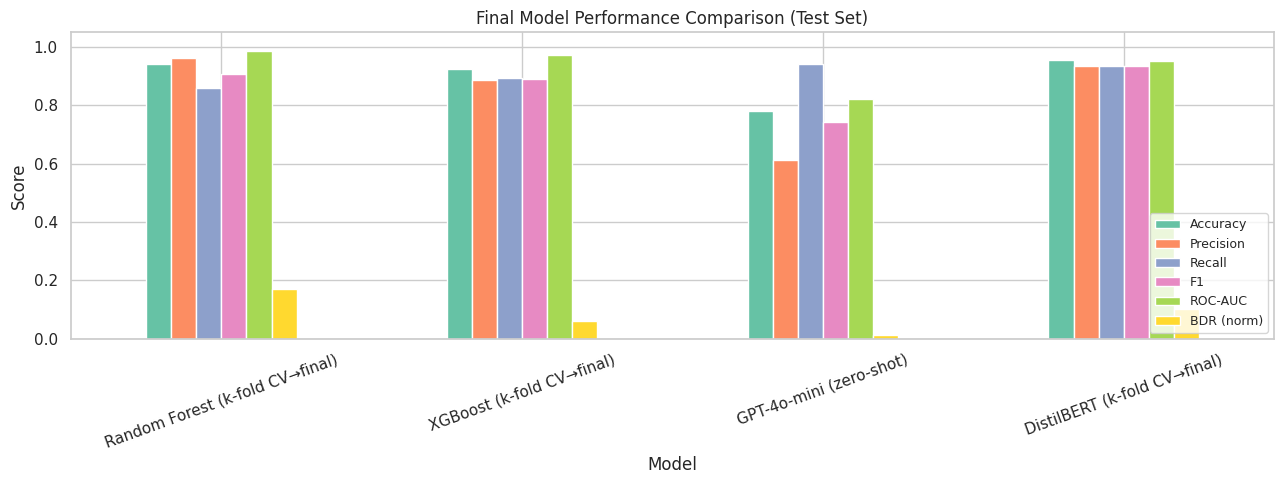


✓ Model comparison table saved


In [37]:
# ════════════════════════════════════════════════════════════════════════════════
# FINAL MODEL COMPARISON: All models on SAME fixed test set
# This is the ONLY authoritative evaluation (not diagnostic k-fold metrics)
# ════════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

print("\n" + "="*70)
print("FINAL MODEL COMPARISON - ON FIXED TEST SET")
print("="*70)
print(f"\nTest set: {len(df_test):,} emails ({(df_test.label==0).sum()} legit, {(df_test.label==1).sum()} phish)")
print(f"Test label distribution: {(df_test.label==0).sum()/(df_test.label==1).sum():.1f}:1 (legit:phish)")

results = []

def _bdr(y_true, y_pred):
    """Balanced Detection Rate (IWSPA 2018, Eq. 8).
    BDR% = 100 * DR / (1 + FP),  where DR = TP / (TP + FN).
    Rewards phishing detection while penalizing false alarms.
    """
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    dr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return round(100 * dr / (1 + fp), 4)

def add_result(name, y_true, y_pred, y_score=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    rec = {
        "Model":     name,
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "F1":        f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_true, y_score if y_score is not None else y_pred),
        "BDR%":      _bdr(y_true, y_pred),
    }
    results.append(rec)

# ────────────────────────────────────────────────────────────────────────────────
# RANDOM FOREST (final model trained on full train set)
# ────────────────────────────────────────────────────────────────────────────────
add_result("Random Forest (k-fold CV→final)", y_test_full, rf_pred_test, rf_proba_test)
print(f"✓ Random Forest added (from final model)")

# ────────────────────────────────────────────────────────────────────────────────
# XGBOOST (final model trained on full train set)
# ────────────────────────────────────────────────────────────────────────────────
if HAS_XGB:
    add_result("XGBoost (k-fold CV→final)", y_test_full, xgb_pred_test, xgb_proba_test)
    print(f"✓ XGBoost added (from final model)")

# ────────────────────────────────────────────────────────────────────────────────
# GPT-4o-mini (evaluated on FULL test set, not subsample)
# ────────────────────────────────────────────────────────────────────────────────
if "df_gpt_test" in dir() and df_gpt_test is not None and "gpt_pred" in df_gpt_test.columns:
    add_result("GPT-4o-mini (zero-shot)",
               df_gpt_test["label"].values,
               df_gpt_test["gpt_pred"].values)
    print(f"✓ GPT-4o-mini added (n={len(df_gpt_test):,}, FULL TEST SET)")
else:
    print("⚠ GPT-4o-mini not available (set OPENAI_API_KEY to run)")

# ────────────────────────────────────────────────────────────────────────────────
# DISTILBERT (final model trained on full train set + hard cases)
# ────────────────────────────────────────────────────────────────────────────────
bert_npy = PROC_DIR / "bert_test_preds.npy"
if bert_npy.exists():
    bert_pred_test = np.load(bert_npy)
    add_result("DistilBERT (k-fold CV→final)", y_test_full, bert_pred_test)
    print(f"✓ DistilBERT added (from final model)")
else:
    print("⚠ DistilBERT predictions not found (run Section 11)")

# ────────────────────────────────────────────────────────────────────────────────
# RESULTS TABLE
# ────────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("MODEL PERFORMANCE ON FIXED TEST SET (Final Evaluation)")
print("="*70)

results_df = pd.DataFrame(results).set_index("Model")
print("\n" + results_df.round(4).to_string())

# Bar chart comparison
plot_df = results_df[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].copy()
plot_df["BDR (norm)"] = results_df["BDR%"] / 100

fig, ax = plt.subplots(figsize=(13, 5))
plot_df.plot(kind="bar", ax=ax, rot=20, ylim=(0, 1.05))
plt.title("Final Model Performance Comparison (Test Set)")
plt.ylabel("Score")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(PROC_DIR / "model_comparison.png", dpi=150)
plt.show()

print("\n✓ Model comparison table saved")


ROC CURVES - All Models on Fixed Test Set


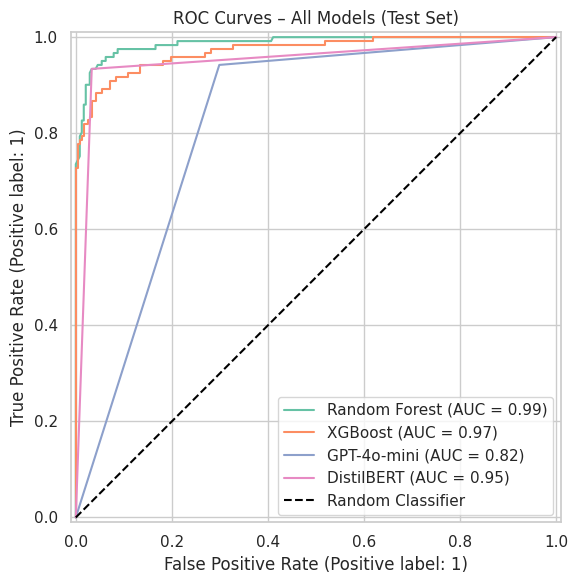


HARD-CASE ANALYSIS: DistilBERT vs GPT

No hard-case overlap in test set (hard cases identified from validation only)
This is expected - hard cases were identified from df_val, not df_test


In [38]:
# ════════════════════════════════════════════════════════════════════════════════
# ROC CURVES - All models on SAME fixed test set
# ════════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("ROC CURVES - All Models on Fixed Test Set")
print("="*70)

fig, ax = plt.subplots(figsize=(8, 6))

# Random Forest
RocCurveDisplay.from_predictions(y_test_full, rf_proba_test, ax=ax, name="Random Forest")

# XGBoost
if HAS_XGB:
    RocCurveDisplay.from_predictions(y_test_full, xgb_proba_test, ax=ax, name="XGBoost")

# GPT (only if available)
if "df_gpt_test" in dir() and df_gpt_test is not None:
    # For GPT (which gives 0/1), treat predictions as probability scores
    gpt_proba_test = df_gpt_test["gpt_pred"].values.astype(float)
    RocCurveDisplay.from_predictions(df_gpt_test["label"].values, gpt_proba_test,
                                     ax=ax, name="GPT-4o-mini")

# DistilBERT
bert_npy = PROC_DIR / "bert_test_preds.npy"
if bert_npy.exists():
    bert_pred_test = np.load(bert_npy)
    RocCurveDisplay.from_predictions(y_test_full, bert_pred_test, ax=ax, name="DistilBERT")

ax.plot([0, 1], [0, 1], "k--", label="Random Classifier")
ax.set_title("ROC Curves – All Models (Test Set)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(PROC_DIR / "roc_all_models.png", dpi=150)
plt.show()

# ════════════════════════════════════════════════════════════════════════════════
# HARD-CASE ANALYSIS: DistilBERT vs GPT on validation-derived hard cases
# ════════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("HARD-CASE ANALYSIS: DistilBERT vs GPT")
print("="*70)

hard_path = PROC_DIR / "gpt_hard_cases_from_val.csv"
bert_npy = PROC_DIR / "bert_test_preds.npy"

if hard_path.exists() and bert_npy.exists():
    hard_df = pd.read_csv(hard_path).reset_index(drop=True)

    # Find overlaps between hard cases and test set
    hard_texts_set = set(hard_df["text"])
    test_texts_with_indices = {text: idx for idx, text in enumerate(df_test["text"])}

    hard_mask = df_test["text"].isin(hard_texts_set)
    n_overlap = hard_mask.sum()

    if n_overlap > 0:
        print(f"\nHard cases in test set: {n_overlap} / {len(df_test)} ({n_overlap/len(df_test)*100:.1f}%)")

        # Get predictions for hard cases from test set
        y_hard_true = y_test_full[hard_mask]
        bert_pred_test = np.load(bert_npy)
        y_hard_bert = bert_pred_test[hard_mask]

        # DistilBERT performance on hard cases
        bert_hard_f1 = f1_score(y_hard_true, y_hard_bert, pos_label=1, zero_division=0)
        print(f"DistilBERT F1 on hard cases    : {bert_hard_f1:.4f}")

        # GPT performance on hard cases (if available)
        if "df_gpt_test" in dir() and df_gpt_test is not None:
            gpt_hard = df_gpt_test[df_gpt_test["text"].isin(hard_texts_set)]
            if len(gpt_hard) > 0:
                gpt_hard_f1 = f1_score(gpt_hard["label"], gpt_hard["gpt_pred"],
                                       pos_label=1, zero_division=0)
                print(f"GPT-4o-mini F1 on hard cases   : {gpt_hard_f1:.4f}")
                print(f"\nImprovement: BERT vs GPT = {bert_hard_f1 - gpt_hard_f1:+.4f}")
    else:
        print("\nNo hard-case overlap in test set (hard cases identified from validation only)")
        print("This is expected - hard cases were identified from df_val, not df_test")
else:
    print("\nHard-case analysis skipped (missing hard cases or BERT predictions)")